In [12]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint
%config InlineBackend.figure_format = "retina"

In [2]:
scans = {}

with uproot.open('scans.root') as f:
    for key in f['Sample_LLH'].keys():
        hist = f['Sample_LLH'][key].to_numpy()
        scans[key] = hist
    

        

In [14]:
scans.keys()

dict_keys(['b_104_sam;1', 'sin2th_12_sam;1', 'sin2th_23_sam;1', 'sin2th_13_sam;1', 'delm2_12_sam;1', 'delm2_23_sam;1', 'delta_cp_sam;1', 'ProdH_sam;1', 'AhtBY_sam;1', 'BhtBY_sam;1', 'CV1uBY_sam;1', 'CV2uBY_sam;1', 'EtaNCEL_sam;1', 'FrAbs_N_sam;1', 'FrAbs_pi_sam;1', 'FrCEx_N_sam;1', 'FrCEx_pi_sam;1', 'FrInel_N_sam;1', 'FrInel_pi_sam;1', 'FrPiProd_N_sam;1', 'FrPiProd_pi_sam;1', 'MFP_N_sam;1', 'MFP_pi_sam;1', 'MaCCRES_sam;1', 'MaNCEL_sam;1', 'MaNCRES_sam;1', 'MvCCRES_sam;1', 'MvNCRES_sam;1', 'NonRESBGvbarnCC1pi_sam;1', 'NonRESBGvbarnCC2pi_sam;1', 'NonRESBGvbarnNC1pi_sam;1', 'NonRESBGvbarnNC2pi_sam;1', 'NonRESBGvbarpCC1pi_sam;1', 'NonRESBGvbarpCC2pi_sam;1', 'NonRESBGvbarpNC1pi_sam;1', 'NonRESBGvbarpNC2pi_sam;1', 'NonRESBGvnCC1pi_sam;1', 'NonRESBGvnCC2pi_sam;1', 'NonRESBGvnNC1pi_sam;1', 'NonRESBGvnNC2pi_sam;1', 'NonRESBGvpCC1pi_sam;1', 'NonRESBGvpCC2pi_sam;1', 'NonRESBGvpNC1pi_sam;1', 'NonRESBGvpNC2pi_sam;1', 'RDecBR1eta_sam;1', 'RDecBR1gamma_sam;1', 'b1_sam;1', 'b2_sam;1', 'b3_sam;1', 'b4_

In [40]:
systs_groups = {
    "CCQE": ['b1', 'b2', 'b3', 'b4'],
    "BodekYang": ['AhtBY', 'BhtBY', 'CV1uBY', 'CV2uBY'],
    'FSI': ['FrAbs_N', 'FrAbs_pi', 'FrCEx_N', 'FrCEx_pi', 'FrInel_N', 'FrInel_pi', 'FrPiProd_N', 'FrPiProd_pi', 'MFP_N', 'MFP_pi'],
    'CCRES': ['MaRes_ResCode0', 'MaRes_ResCode1', 'MvRes_ResCode0', 'MvRes_ResCode1', 'RDecBR1eta', 'RDecBR1gamma'],
    'NC': ['MaNCRES', 'MvNCRES', 'MaNCEL', 'EtaNCEL'],
    'MEC': ['C12ToAr40_2p2hScaling_nu', 'C12ToAr40_2p2hScaling_nubar'], #DecayAngMECVariationResponse
    'CCSIS': ['NonRESBGvbarnCC1pi', 'NonRESBGvbarnCC2pi', 'NonRESBGvbarpCC1pi', 'NonRESBGvbarpCC2pi', 'NonRESBGvnCC1pi', 'NonRESBGvnCC2pi', 'NonRESBGvpCC1pi', 'NonRESBGvpCC2pi'],
    'NCSIS': ['NonRESBGvbarnNC1pi', 'NonRESBGvbarnNC2pi', 'NonRESBGvbarpNC1pi', 'NonRESBGvbarpNC2pi', 'NonRESBGvnNC1pi', 'NonRESBGvnNC2pi', 'NonRESBGvpNC1pi', 'NonRESBGvpNC2pi'],
    "Others": ['nucleus_radius', 'surface_thickness', 'nuenuebar_xsec_ratio', 'nuenumu_xsec_ratio'],
    'osc': ['delm2_12', 'delm2_23', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delta_cp']
}



Text(0.5, 1.0, 'Scan for delta_cp')

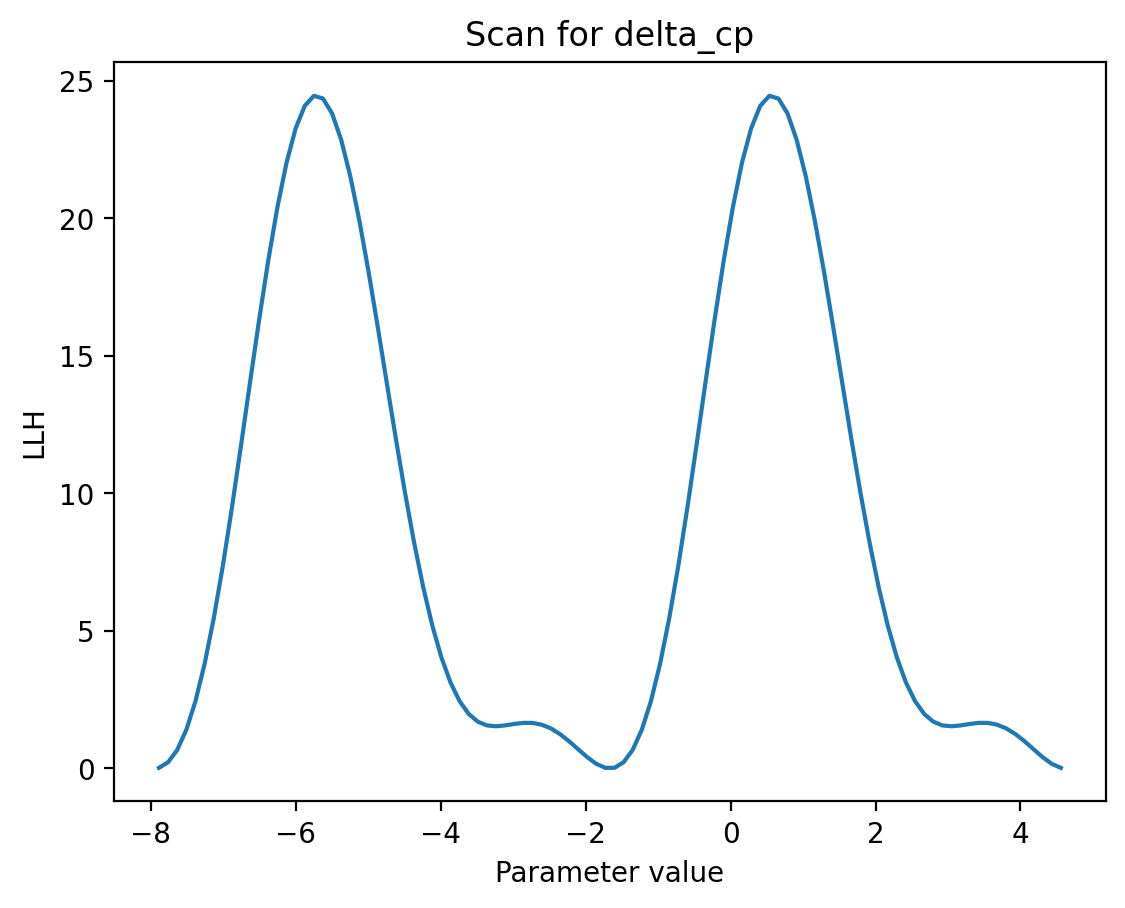

In [19]:
plt.figure()
plt.plot(scans['delta_cp_sam;1'][1][:-1], scans['delta_cp_sam;1'][0], label='delta_cp')
plt.xlabel('Parameter value')
plt.ylabel('LLH')
plt.title(f'Scan for delta_cp')

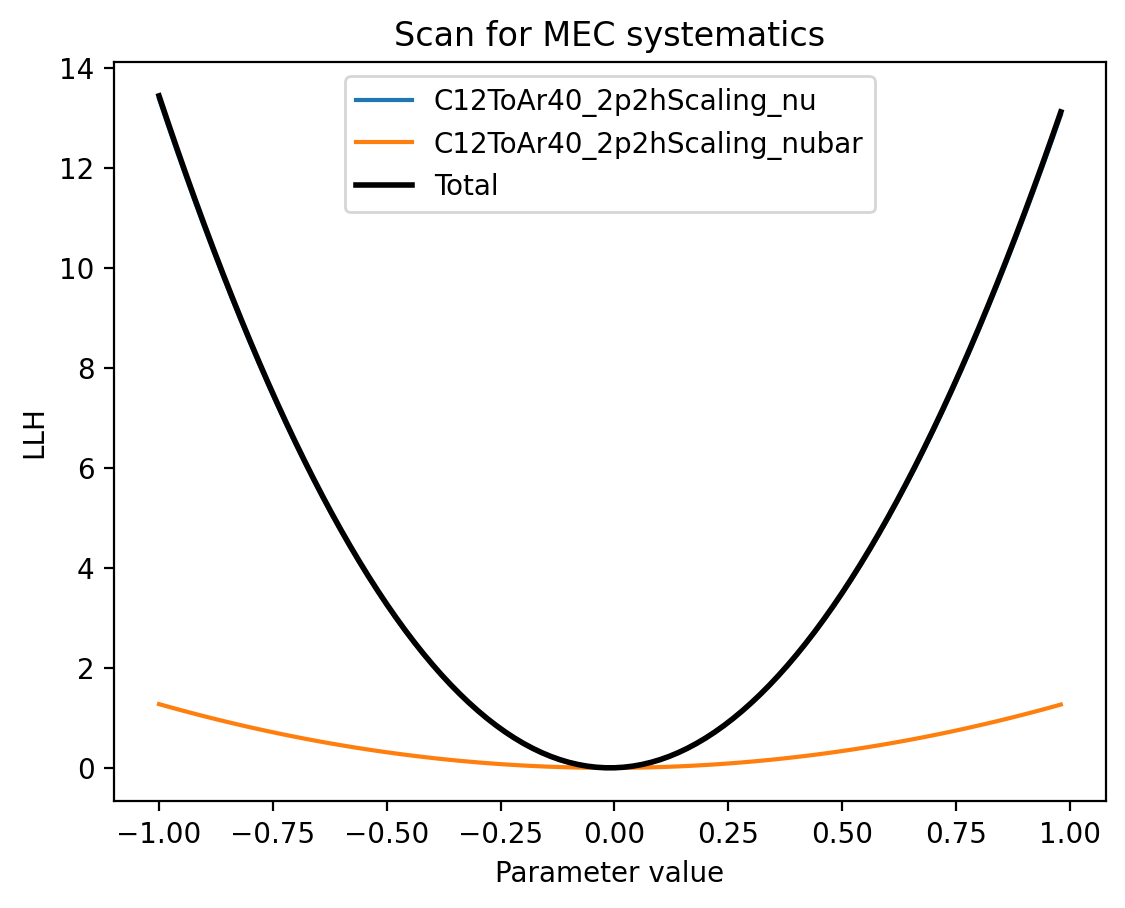

In [41]:
systs = systs_groups['MEC']
plt.figure()
sum_sq = 0
for s in systs:
    scan_name = f'{s}_sam;1'
    scan = scans[scan_name]

    sum_sq += scan[0]**2
    plt.plot(scan[1][:-1], scan[0], label=s)
plt.plot(scan[1][:-1], np.sqrt(sum_sq), label='Total', color='black', linewidth=2)
plt.xlabel('Parameter value')
plt.ylabel('LLH')
plt.title(f'Scan for MEC systematics')
plt.legend()